In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_style("whitegrid")

In [32]:
df = pd.read_csv('osu_plays.csv')
df.head(5)

,song_title,artist,genre,id,beatmap_id,date_started,date_ended,accuracy,max_combo_player,max_combo_beatmap,...,ar,cs,bpm,hit_length,count_circles,count_sliders,count_spinners,difficulty_rating,beatmap_type,played_before
0,Anoko Secret,Eve,Rock,6176870141,1788240,2026-02-07 00:10:01+08:00,2026-02-07 00:11:48+08:00,90.58,320,643,...,9.0,4.0,160.0,100,276,180,2,4.81082,Hybrid,True
1,Anoko Secret,Eve,Rock,6176913489,1788240,2026-02-07 00:18:35+08:00,2026-02-07 00:20:21+08:00,88.97,185,643,...,9.0,4.0,160.0,100,276,180,2,4.81082,Hybrid,True
2,Rubik's Cube,Hatsune Miku,Rock,6176949608,114635,2026-02-07 00:24:38+08:00,2026-02-07 00:27:31+08:00,88.20,93,1027,...,9.0,4.0,174.0,151,470,246,1,5.53040,Hybrid,True
3,Playing With Fire,kors k,Video Game,6177128241,2015158,2026-02-07 01:00:34+08:00,2026-02-07 01:02:20+08:00,89.57,316,617,...,9.0,4.0,160.0,93,262,136,4,4.55318,Tech,False
4,Koi no Hime Hime Pettanko,*namirin,Anime,6177375094,1053519,2026-02-07 01:48:38+08:00,2026-02-07 01:50:15+08:00,95.68,461,502,...,9.0,4.0,178.0,92,213,143,0,4.62552,Jump,True


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   song_title         301 non-null    str    
 1   artist             301 non-null    str    
 2   genre              301 non-null    str    
 3   id                 301 non-null    int64  
 4   beatmap_id         301 non-null    int64  
 5   date_started       301 non-null    str    
 6   date_ended         301 non-null    str    
 7   accuracy           301 non-null    float64
 8   max_combo_player   301 non-null    int64  
 9   max_combo_beatmap  301 non-null    int64  
 10  is_perfect_combo   301 non-null    bool   
 11  passed             301 non-null    bool   
 12  max_great          301 non-null    int64  
 13  great              301 non-null    int64  
 14  ok                 301 non-null    int64  
 15  meh                244 non-null    float64
 16  miss               298 non-null    fl

In [34]:
display(df.describe())

,id,beatmap_id,accuracy,max_combo_player,max_combo_beatmap,max_great,great,ok,meh,miss,ar,cs,bpm,hit_length,count_circles,count_sliders,count_spinners,difficulty_rating
count,3.010000e+02,3.010000e+02,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,244.000000,298.00000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000
mean,6.198493e+09,1.342158e+06,91.712824,353.451827,1196.504983,783.893688,655.624585,75.667774,9.073770,17.42953,9.125581,3.989701,179.166678,176.737542,462.780731,319.445183,1.667774,5.469508
std,1.434187e+07,1.086915e+06,5.480449,227.062095,572.397156,352.386741,306.573224,68.368725,9.915833,13.32083,0.191425,0.233224,22.735525,73.626949,238.624947,164.734072,1.623553,0.400527
min,6.176870e+09,1.114390e+05,70.230000,68.000000,402.000000,282.000000,86.000000,2.000000,1.000000,1.00000,8.000000,3.000000,87.000000,73.000000,149.000000,74.000000,0.000000,4.447440
25%,6.186523e+09,4.875890e+05,88.540000,189.000000,745.000000,503.000000,411.000000,23.000000,2.000000,7.00000,9.000000,4.000000,170.000000,113.000000,294.000000,175.000000,1.000000,5.192410
50%,6.193135e+09,1.053519e+06,92.760000,293.000000,1093.000000,733.000000,597.000000,54.000000,6.000000,15.00000,9.000000,4.000000,175.000000,164.000000,422.000000,287.000000,1.000000,5.452380
75%,6.213224e+09,1.744010e+06,95.820000,452.000000,1520.000000,963.000000,821.000000,112.000000,12.250000,24.00000,9.200000,4.000000,190.000000,216.000000,545.000000,416.000000,2.000000,5.796730
max,6.224370e+09,5.194045e+06,99.230000,1301.000000,3273.000000,1880.000000,1747.000000,427.000000,65.000000,68.00000,10.000000,5.700000,320.000000,441.000000,1338.000000,870.000000,8.000000,6.305370


# Data Pre-processing

In [35]:
df.isnull().sum()

song_title            0
artist                0
genre                 0
id                    0
beatmap_id            0
date_started          0
date_ended            0
accuracy              0
max_combo_player      0
max_combo_beatmap     0
is_perfect_combo      0
passed                0
max_great             0
great                 0
ok                    0
meh                  57
miss                  3
ar                    0
cs                    0
bpm                   0
hit_length            0
count_circles         0
count_sliders         0
count_spinners        0
difficulty_rating     0
beatmap_type          0
played_before         0
dtype: int64

In [36]:
df['meh'] = df['meh'].fillna(0)
df['miss'] = df['miss'].fillna(0)

print(df.isnull().sum())

song_title           0
artist               0
genre                0
id                   0
beatmap_id           0
date_started         0
date_ended           0
accuracy             0
max_combo_player     0
max_combo_beatmap    0
is_perfect_combo     0
passed               0
max_great            0
great                0
ok                   0
meh                  0
miss                 0
ar                   0
cs                   0
bpm                  0
hit_length           0
count_circles        0
count_sliders        0
count_spinners       0
difficulty_rating    0
beatmap_type         0
played_before        0
dtype: int64


In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df['combo_ratio'] = (df['max_combo_player'] / df['max_combo_beatmap'])
print("Combo Completion:")
print(f"  Range: {df['combo_ratio'].min():.2f}% to {df['combo_ratio'].max():.2f}%")
print(f"  Mean: {df['combo_ratio'].mean():.2f}%, SD: {df['combo_ratio'].std():.2f}%")
print()

df['total_objects'] = df['count_circles'] + df['count_sliders'] + df['count_spinners']
df['object_density'] = df['total_objects'] / df['hit_length']
print("Object Density:")
print(f"  Range: {df['object_density'].min():.2f} to {df['object_density'].max():.2f} objects/sec")
print(f"  Mean: {df['object_density'].mean():.2f} objects/sec")
print()

df['miss_rate'] = (df['miss'] / df['total_objects'])
print("Miss Rate:")
print(f"  Range: {df['miss_rate'].min():.2f}% to {df['miss_rate'].max():.2f}%")
print(f"  Mean: {df['miss_rate'].mean():.2f}%")
print()

df['date_started'] = pd.to_datetime(df['date_started'])
df = df.sort_values('date_started').reset_index(drop=True)

df['day'] = (df['date_started'] - df['date_started'].min()).dt.days
print("Days since start:")
print(f"  Range: 0 to {df['day'].max()} days")
print()

df['hour'] = df['date_started'].dt.hour
print("Hour of day:")
print(f"  Range: {df['hour'].min()} to {df['hour'].max()}")
print()

Combo Completion:
  Range: 0.04% to 1.00%
  Mean: 0.33%, SD: 0.21%

Object Density:
  Range: 2.95 to 7.67 objects/sec
  Mean: 4.44 objects/sec

Miss Rate:
  Range: 0.00% to 0.10%
  Mean: 0.02%

Days since start:
  Range: 0 to 8 days

Hour of day:
  Range: 0 to 23



# EDA

In [39]:
df = df.drop(['song_title','artist','id','beatmap_id','date_started', 'date_ended'], axis=1)
df.head(5)

,genre,accuracy,max_combo_player,max_combo_beatmap,is_perfect_combo,passed,max_great,great,ok,meh,...,count_spinners,difficulty_rating,beatmap_type,played_before,combo_ratio,total_objects,object_density,miss_rate,day,hour
0,Rock,90.58,320,643,False,True,458,386,63,2.0,...,2,4.81082,Hybrid,True,0.497667,458,4.580000,0.015284,0,0
1,Rock,88.97,185,643,False,True,458,377,59,8.0,...,2,4.81082,Hybrid,True,0.287714,458,4.580000,0.030568,0,0
2,Rock,88.20,93,1027,False,True,717,592,90,3.0,...,1,5.53040,Hybrid,True,0.090555,717,4.748344,0.044630,0,0
3,Video Game,89.57,316,617,False,True,402,337,47,9.0,...,4,4.55318,Tech,False,0.512156,402,4.322581,0.022388,0,1
4,Anime,95.68,461,502,False,True,356,330,21,3.0,...,0,4.62552,Jump,True,0.918327,356,3.869565,0.005618,0,1


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   genre              301 non-null    str    
 1   accuracy           301 non-null    float64
 2   max_combo_player   301 non-null    int64  
 3   max_combo_beatmap  301 non-null    int64  
 4   is_perfect_combo   301 non-null    bool   
 5   passed             301 non-null    bool   
 6   max_great          301 non-null    int64  
 7   great              301 non-null    int64  
 8   ok                 301 non-null    int64  
 9   meh                301 non-null    float64
 10  miss               301 non-null    float64
 11  ar                 301 non-null    float64
 12  cs                 301 non-null    float64
 13  bpm                301 non-null    float64
 14  hit_length         301 non-null    int64  
 15  count_circles      301 non-null    int64  
 16  count_sliders      301 non-null    in

## Univariate Analysis

Numeric

In [41]:
numeric_columns = [
    'accuracy', 'max_combo_player', 'max_combo_beatmap', 'max_great', 
    'great', 'ok', 'meh', 'miss', 'ar', 'cs', 'bpm', 'hit_length', 
    'count_circles', 'count_sliders', 'count_spinners', 'difficulty_rating', 
    'combo_ratio', 'miss_rate', 'total_objects', 'object_density', 'hour', 'day'
]

summary_stats = df[numeric_columns].describe().T
print("Numeric Feature Summary")
print(summary_stats)

Numeric Feature Summary
                   count         mean         std         min         25%  \
accuracy           301.0    91.712824    5.480449   70.230000   88.540000   
max_combo_player   301.0   353.451827  227.062095   68.000000  189.000000   
max_combo_beatmap  301.0  1196.504983  572.397156  402.000000  745.000000   
max_great          301.0   783.893688  352.386741  282.000000  503.000000   
great              301.0   655.624585  306.573224   86.000000  411.000000   
ok                 301.0    75.667774   68.368725    2.000000   23.000000   
meh                301.0     7.355482    9.608497    0.000000    1.000000   
miss               301.0    17.255814   13.367037    0.000000    7.000000   
ar                 301.0     9.125581    0.191425    8.000000    9.000000   
cs                 301.0     3.989701    0.233224    3.000000    4.000000   
bpm                301.0   179.166678   22.735525   87.000000  170.000000   
hit_length         301.0   176.737542   73.626949   

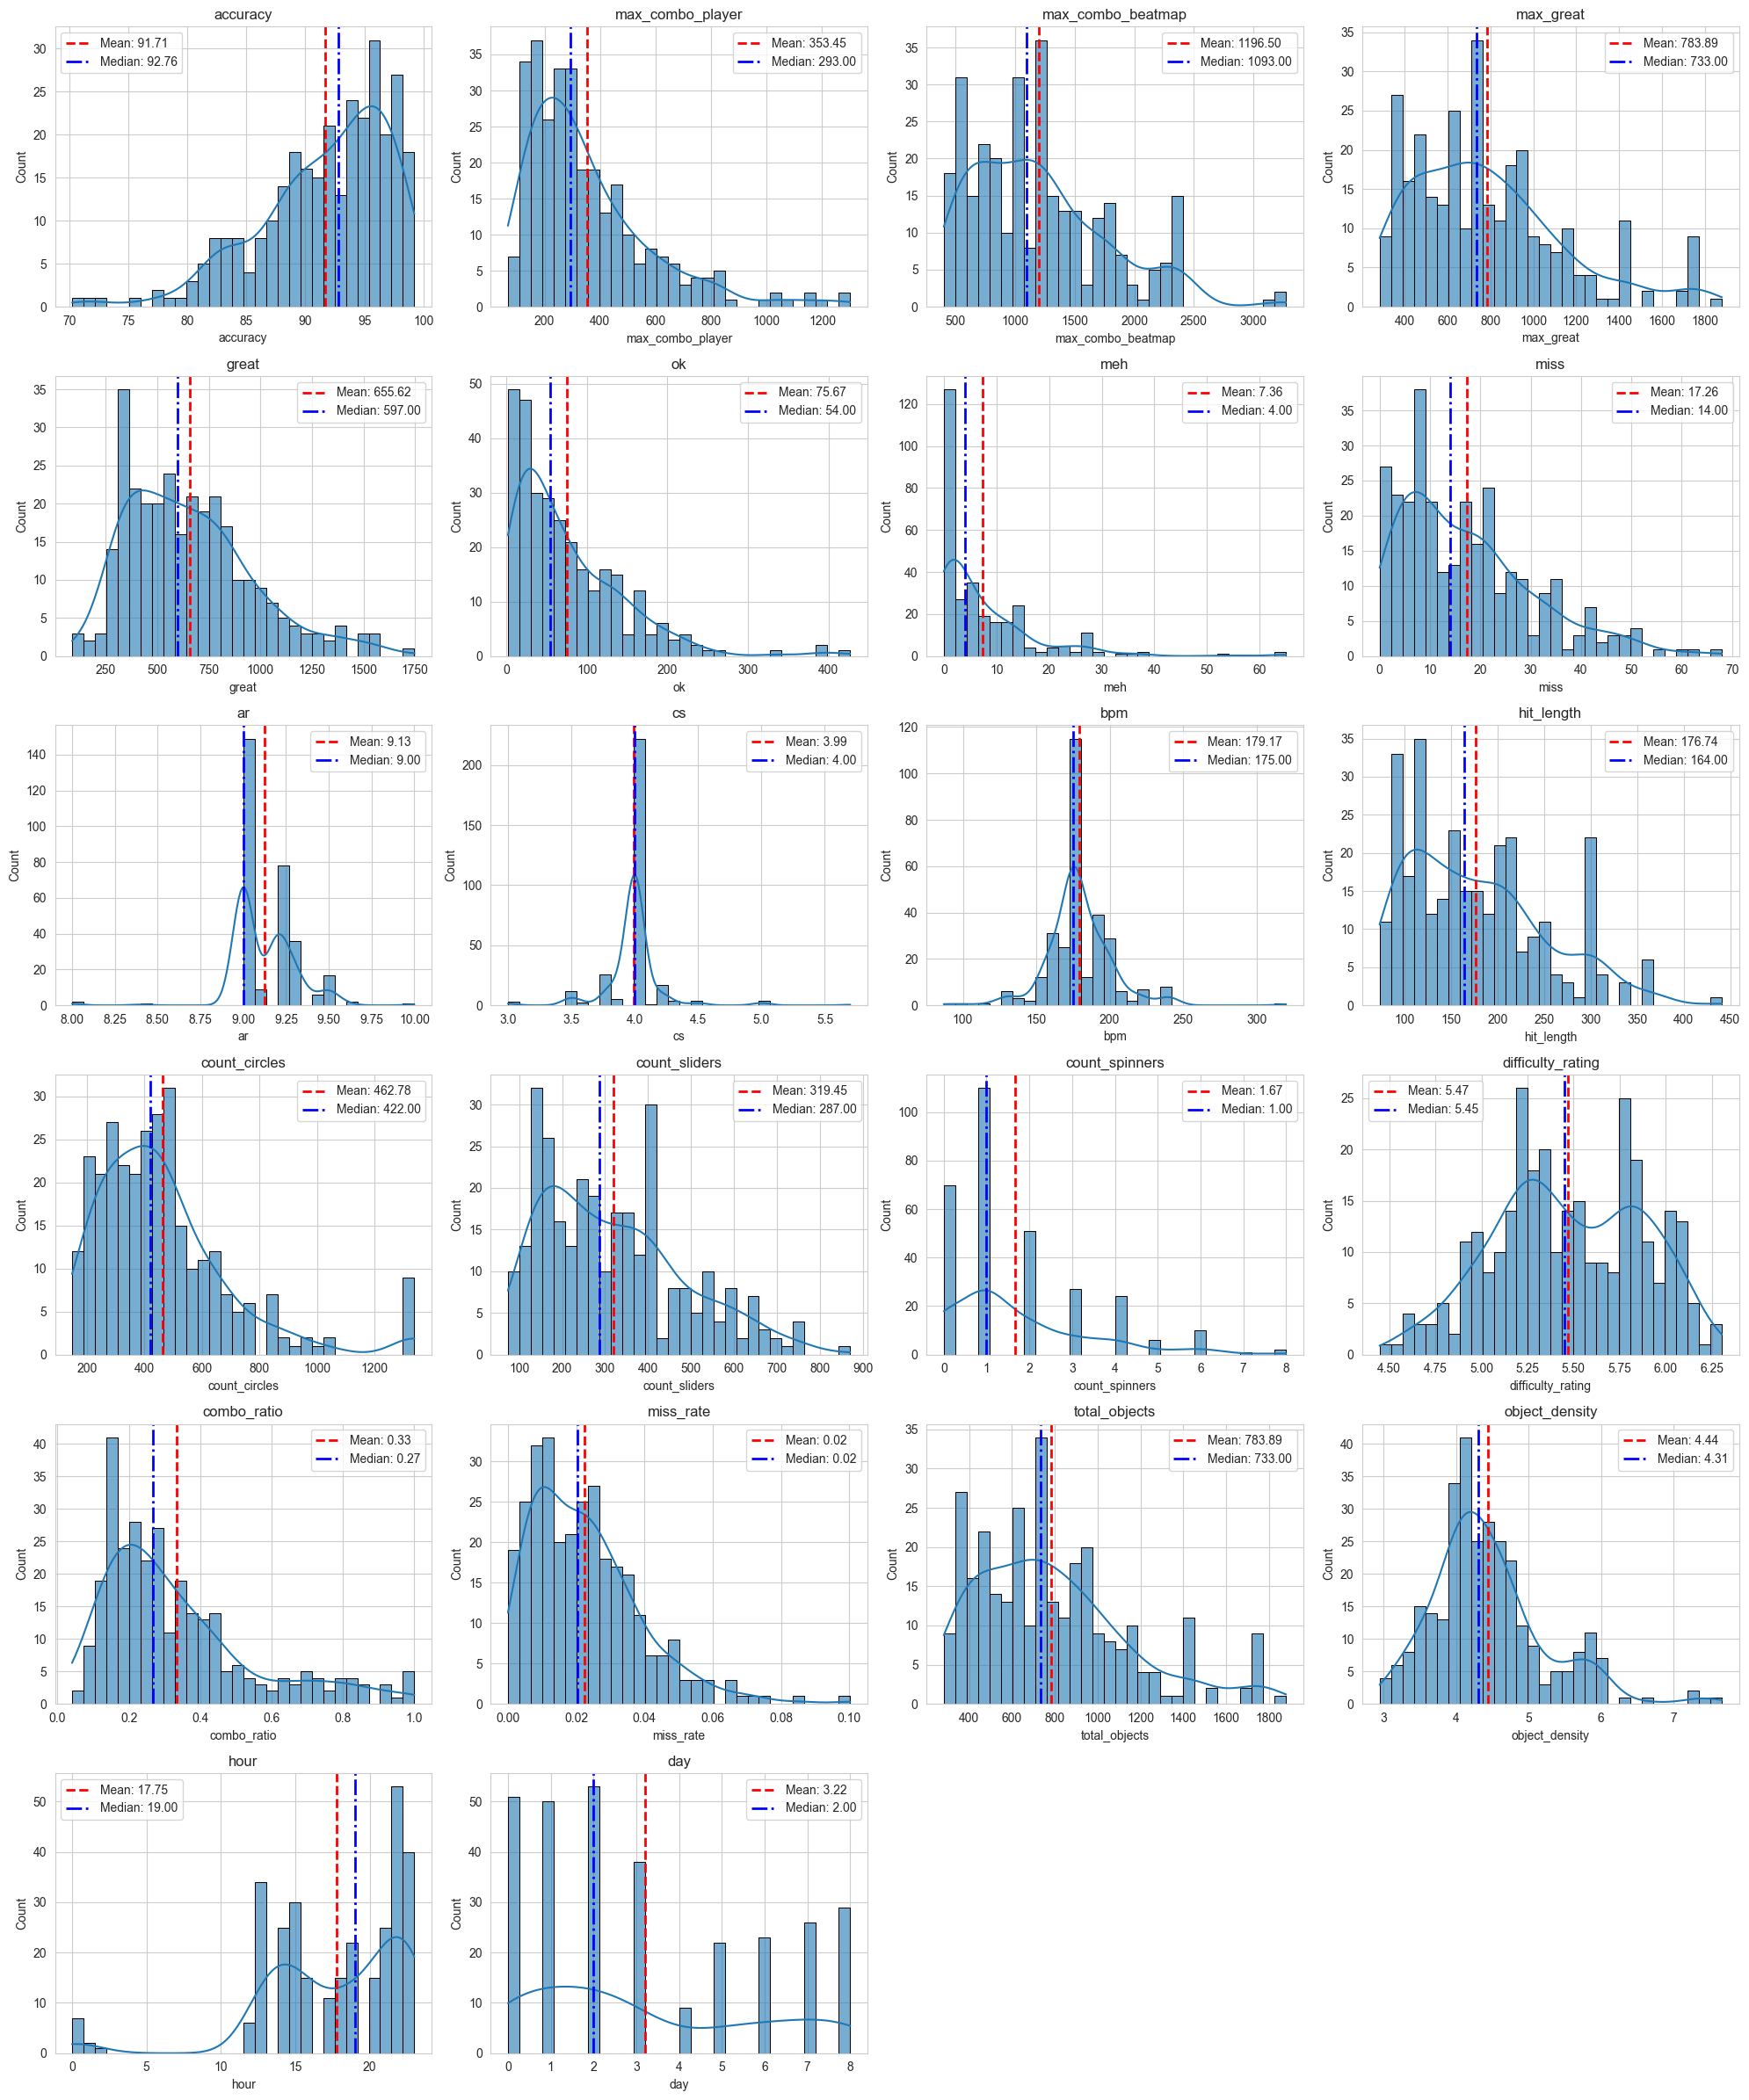

In [42]:
cols_per_row = 4
rows = (len(numeric_columns) + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numeric_columns):
    column_data = df[col].dropna()
    
    sns.histplot(column_data, bins=30, kde=True, ax=axes[idx], edgecolor='black', alpha=0.6)
    
    mean_val = column_data.mean()
    median_val = column_data.median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='blue', linestyle='-.', linewidth=2, label=f'Median: {median_val:.2f}')

    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].legend()

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("performance_metrics_hist.png", dpi=300)

Categorical and Boolean

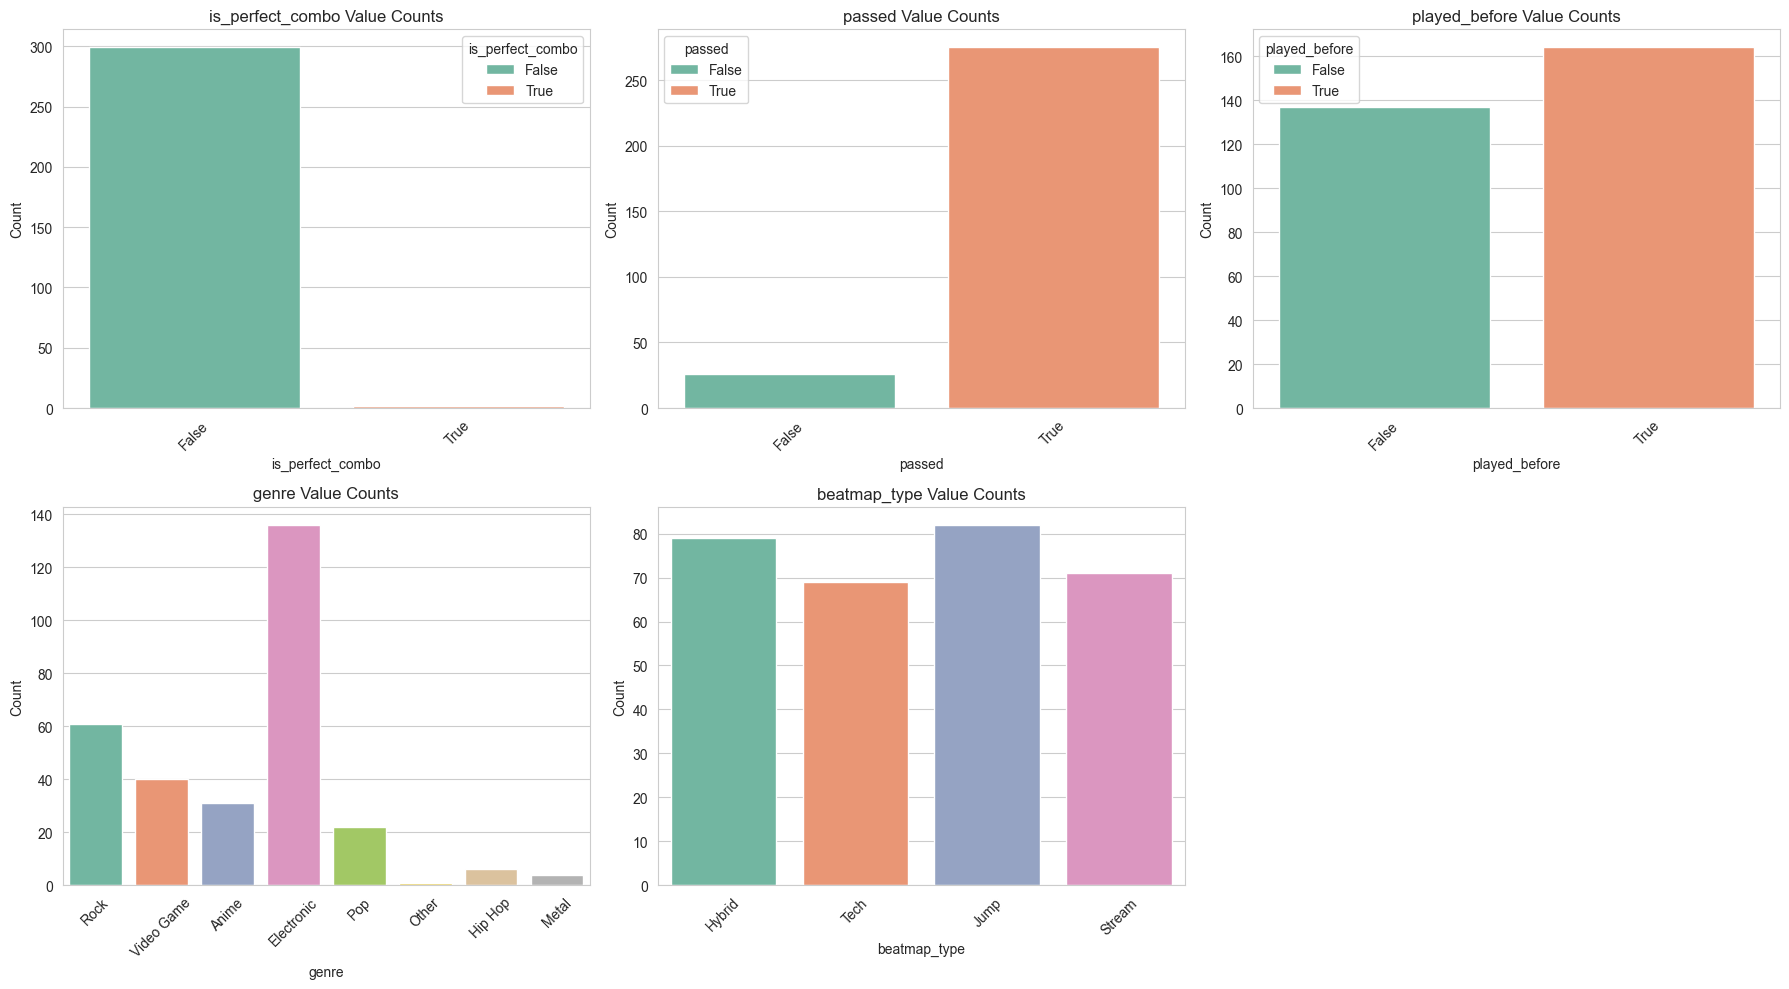

is_perfect_combo
False    299
True       2
Name: count, dtype: int64


passed
True     275
False     26
Name: count, dtype: int64


played_before
True     164
False    137
Name: count, dtype: int64


genre
Electronic    136
Rock           61
Video Game     40
Anime          31
Pop            22
Hip Hop         6
Metal           4
Other           1
Name: count, dtype: int64


beatmap_type
Jump      82
Hybrid    79
Stream    71
Tech      69
Name: count, dtype: int64




In [43]:
cat_bool_cols = ['is_perfect_combo', 'passed', 'played_before', 'genre', 'beatmap_type']

n_cols = 3
n_rows = (len(cat_bool_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*5))
axes = axes.flatten()

for i, col in enumerate(cat_bool_cols):
    sns.countplot(x=col, data=df, hue=col, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} Value Counts')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

for col in cat_bool_cols:
    print(df[col].value_counts())
    print("\n")

## Bivariate Analysis

Numeric and Numeric (Based on Combo Ratio)

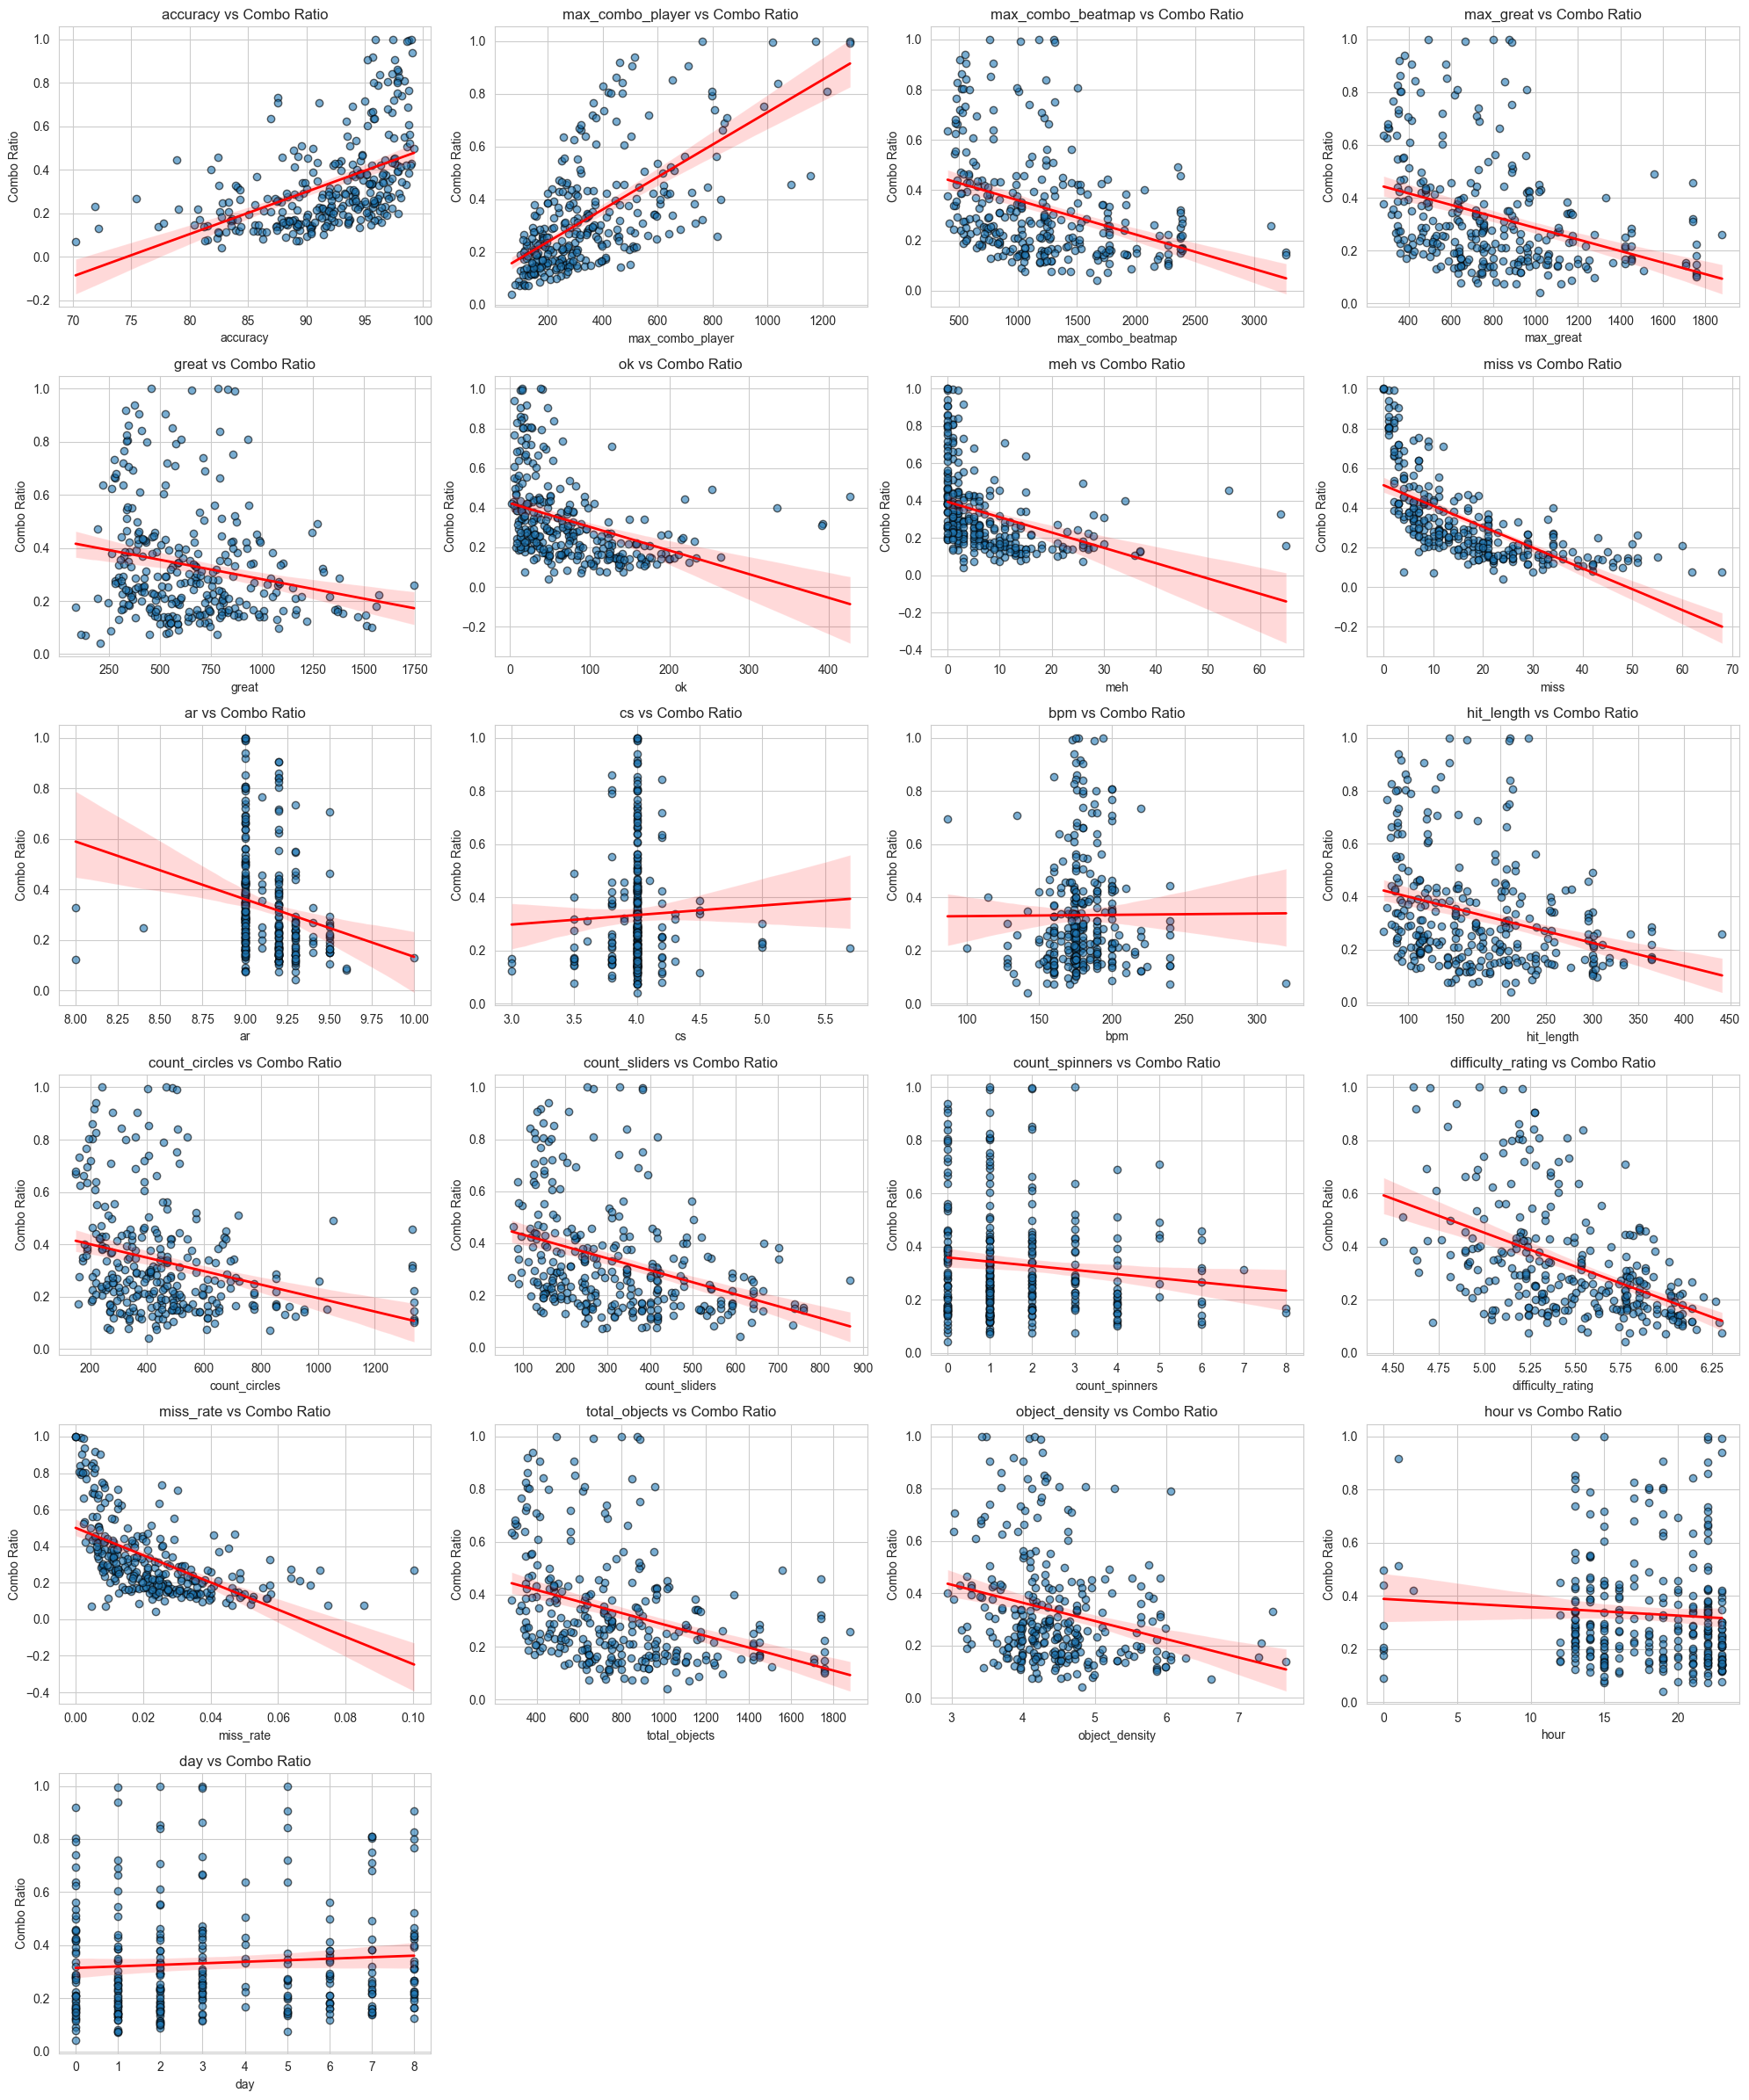

In [44]:
numeric_columns = [
    'accuracy', 'max_combo_player', 'max_combo_beatmap', 'max_great', 
    'great', 'ok', 'meh', 'miss', 'ar', 'cs', 'bpm', 'hit_length', 
    'count_circles', 'count_sliders', 'count_spinners', 'difficulty_rating', 
    'miss_rate', 'total_objects', 'object_density', 'hour', 'day'
]

cols_per_row = 4
rows = (len(numeric_columns) + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numeric_columns):
    sns.regplot(x=col, y='combo_ratio', data=df, ax=axes[idx],
                scatter_kws={'alpha':0.6, 'edgecolor':'black'},
                line_kws={'color':'red', 'linewidth':2})
    
    axes[idx].set_title(f'{col} vs Combo Ratio')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Combo Ratio')

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Numeric and Categorical/Boolean

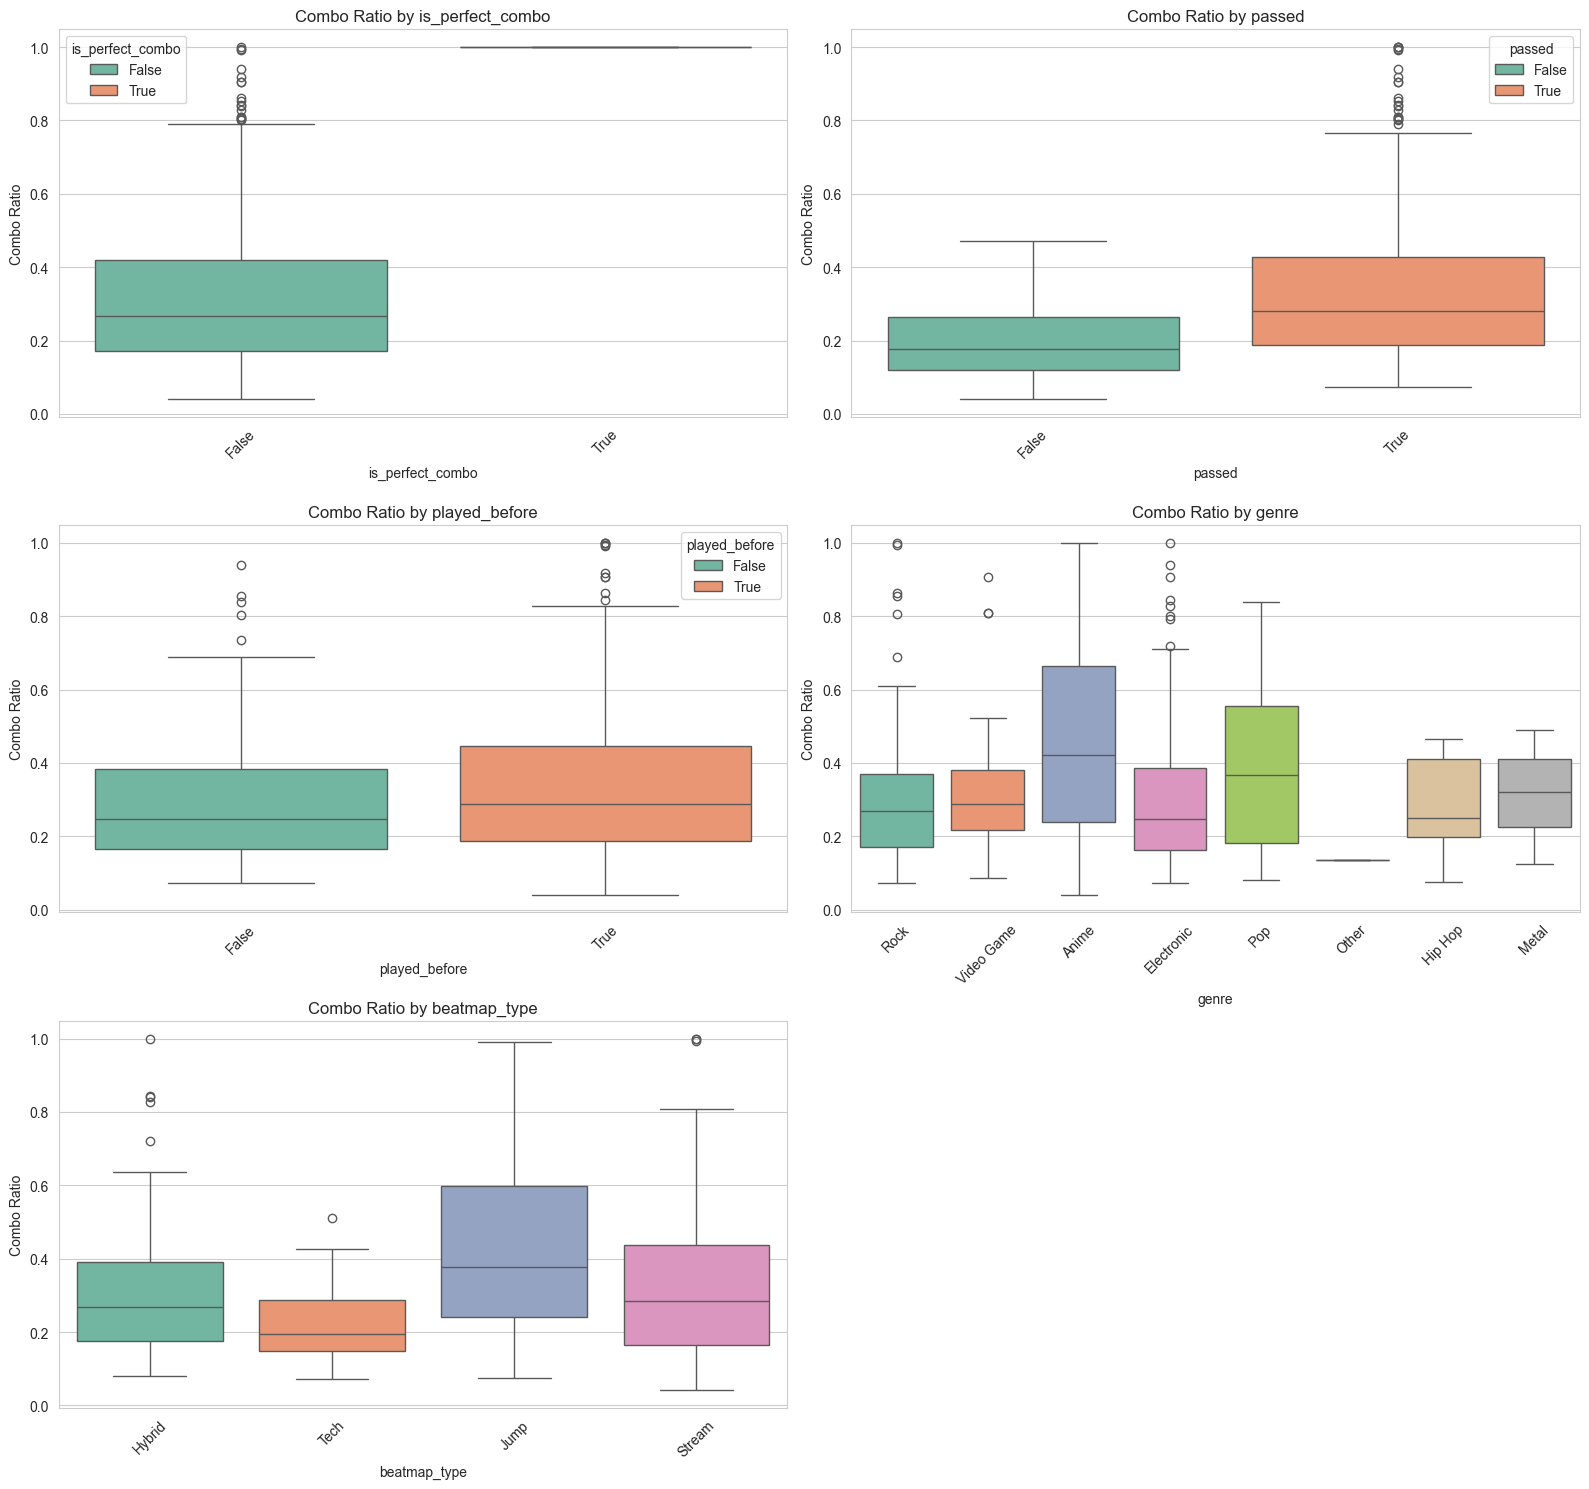

In [45]:
n_cols = 2
n_rows = (len(cat_bool_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*8, n_rows*5))
axes = axes.flatten()

for idx, col in enumerate(cat_bool_cols):
    sns.boxplot(x=col, y='combo_ratio', data=df, hue=col, palette='Set2', ax=axes[idx])
    axes[idx].set_title(f'Combo Ratio by {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Combo Ratio')
    axes[idx].tick_params(axis='x', rotation=45)

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [46]:
df.groupby('is_perfect_combo')['combo_ratio'].agg(['mean', 'std'])

,mean,std
is_perfect_combo,,
False,0.328289,0.206569
True,1.000000,0.000000


In [47]:
df.groupby('passed')['combo_ratio'].agg(['mean', 'std'])

,mean,std
passed,,
False,0.199152,0.111672
True,0.345383,0.216074


In [48]:
df.groupby('played_before')['combo_ratio'].agg(['mean', 'std'])

,mean,std
played_before,,
False,0.294116,0.172169
True,0.365027,0.237647


In [49]:
df.groupby('genre')['combo_ratio'].agg(['mean', 'std'])

,mean,std
genre,,
Anime,0.463050,0.264858
Electronic,0.301452,0.195623
Hip Hop,0.280921,0.154244
Metal,0.314309,0.157861
Other,0.135895,NaN
Pop,0.400965,0.238699
Rock,0.324665,0.217327
Video Game,0.327547,0.182166


In [50]:
df.groupby('beatmap_type')['combo_ratio'].agg(['mean', 'std'])

,mean,std
beatmap_type,,
Hybrid,0.313975,0.192519
Jump,0.431887,0.232722
Stream,0.348840,0.237478
Tech,0.219883,0.098185


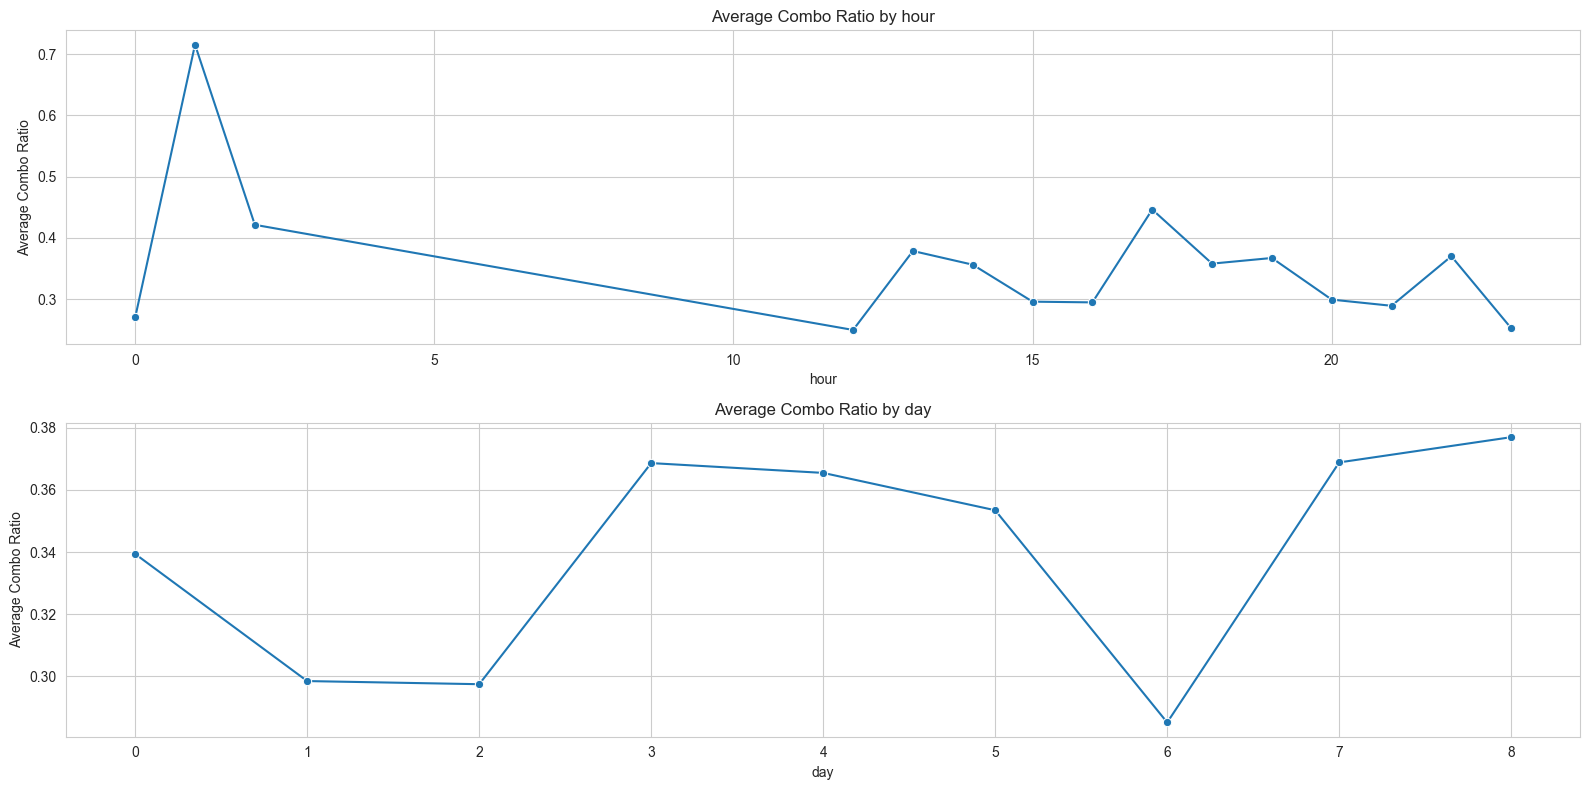

In [51]:
time_columns = ['hour', 'day']

cols_per_row = 1
rows = (len(time_columns) + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, rows * 4))
axes = axes.flatten()

for idx, col in enumerate(time_columns):
    grouped = df.groupby(col)['combo_ratio'].mean().reset_index()
    
    sns.lineplot(x=col, y='combo_ratio', data=grouped, ax=axes[idx], marker='o')
    
    axes[idx].set_title(f'Average Combo Ratio by {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Average Combo Ratio')

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Statistical Test

In [52]:
numeric_columns = [
    'accuracy', 'max_combo_player', 'max_combo_beatmap', 'max_great', 
    'great', 'ok', 'meh', 'miss', 'ar', 'cs', 'bpm', 'hit_length', 
    'count_circles', 'count_sliders', 'count_spinners', 'difficulty_rating', 
    'miss_rate', 'total_objects', 'object_density', 'day', 'hour'
]

correlations = df[numeric_columns + ['combo_ratio']].corr()['combo_ratio'].sort_values(key=abs, ascending=False)
print(correlations)

combo_ratio          1.000000
miss                -0.657988
max_combo_player     0.654486
miss_rate           -0.564930
accuracy             0.499882
difficulty_rating   -0.478714
ok                  -0.382654
meh                 -0.370812
max_combo_beatmap   -0.367733
max_great           -0.361716
total_objects       -0.361716
count_sliders       -0.354647
hit_length          -0.301715
count_circles       -0.288520
object_density      -0.255313
great               -0.210544
ar                  -0.205260
count_spinners      -0.119010
day                  0.072402
hour                -0.071469
cs                   0.039272
bpm                  0.005185
Name: combo_ratio, dtype: float64


In [53]:
target = 'combo_ratio'

numeric_features = ['miss','max_combo_player','miss_rate','accuracy','difficulty_rating',
                    'ok','meh','max_combo_beatmap','total_objects','max_great','count_sliders',
                    'hit_length', 'count_circles', 'object_density', 'great', 'ar']

categorical_features = ['beatmap_type','genre']
boolean_features = ['is_perfect_combo','played_before','passed']

In [54]:
print("=== Numeric Features ===")
print(f"{'Feature':<20} {'r':>7} {'p-value':>10}")
print("-" * 40)

for col in numeric_features:
    r, p = stats.pearsonr(df[col], df[target])

    if p < 0.001:
        p_display = "<0.0001"
    else:
        p_display = f"{p:.4f}"
    print(f"{col:<20} {r:>7.3f} {p_display:>10}")

=== Numeric Features ===
Feature                    r    p-value
----------------------------------------
miss                  -0.658    <0.0001
max_combo_player       0.654    <0.0001
miss_rate             -0.565    <0.0001
accuracy               0.500    <0.0001
difficulty_rating     -0.479    <0.0001
ok                    -0.383    <0.0001
meh                   -0.371    <0.0001
max_combo_beatmap     -0.368    <0.0001
total_objects         -0.362    <0.0001
max_great             -0.362    <0.0001
count_sliders         -0.355    <0.0001
hit_length            -0.302    <0.0001
count_circles         -0.289    <0.0001
object_density        -0.255    <0.0001
great                 -0.211    <0.0001
ar                    -0.205    <0.0001


In [55]:
print("\n=== Boolean Features ===")
print(f"{'Feature':<20} {'U-stat':>10} {'p-value':>10} {'r':>8}")
print("-" * 55)

for col in boolean_features:
    group_true = df[df[col]==True][target]
    group_false = df[df[col]==False][target]

    n1, n2 = len(group_true), len(group_false)

    u_stat, p_val = stats.mannwhitneyu(group_true, group_false, alternative='two-sided')

    u_mean = n1 * n2 / 2
    u_std = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (u_stat - u_mean) / u_std
    r = z / np.sqrt(n1 + n2)

    if p_val < 0.001:
        p_display = "<0.0001"
    else:
        p_display = f"{p_val:.4f}"
    
    print(f"{col:<20} {u_stat:>10.3f} {p_display:>10} {r:>8.3f}")


=== Boolean Features ===
Feature                  U-stat    p-value        r
-------------------------------------------------------
is_perfect_combo        598.000     0.0150    0.140
played_before         12928.500     0.0243    0.130
passed                 5165.000    <0.0001    0.216


In [58]:
print("\n=== Categorical Features ===")
print(f"{'Feature':<20} {'F-stat':>10} {'p-value':>10} {'η²':>8}")
print("-" * 55)

for col in categorical_features:
    groups = [df[df[col]==val][target] for val in df[col].unique()]
    f_stat, p_val = stats.f_oneway(*groups)
    
    k = len(groups)
    N = sum(len(g) for g in groups)

    eta_sq = (f_stat * (k - 1)) / (f_stat * (k - 1) + (N - k))

    if p_val < 0.001:
        p_display = "<0.0001"
    else:
        p_display = f"{p_val:.4f}"
    
    print(f"{col:<20} {f_stat:>10.3f} {p_display:>10} {eta_sq:>8.3f}")


=== Categorical Features ===
Feature                  F-stat    p-value       η²
-------------------------------------------------------
beatmap_type             14.425    <0.0001    0.127
genre                     2.694     0.0102    0.060


# Correlation Analysis

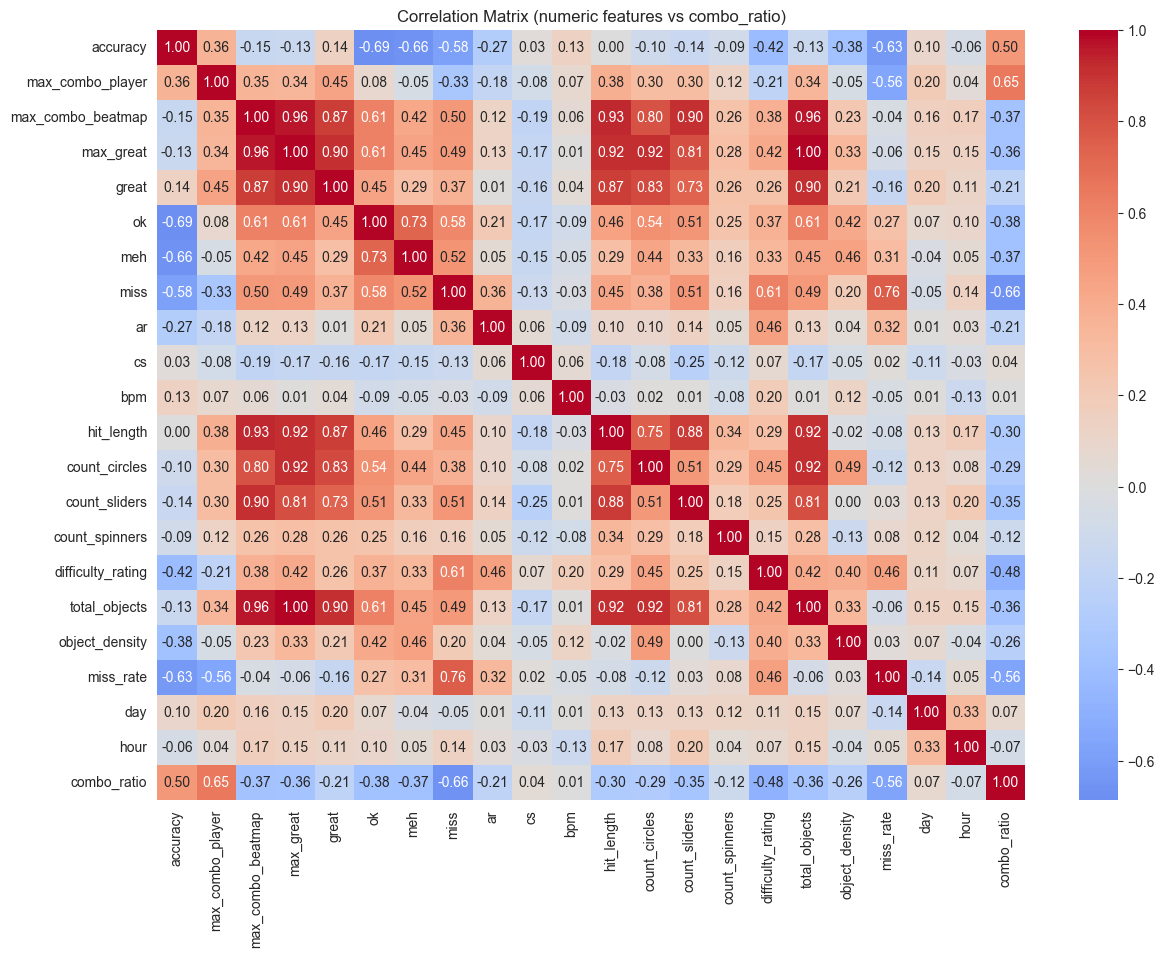

In [57]:
numeric_columns = [
    'accuracy', 'max_combo_player', 'max_combo_beatmap', 'max_great',
    'great', 'ok', 'meh', 'miss', 'ar', 'cs', 'bpm', 'hit_length',
    'count_circles', 'count_sliders', 'count_spinners', 'difficulty_rating',
    'total_objects', 'object_density', 'miss_rate', 'day', 'hour'
]

corr = df[numeric_columns + ['combo_ratio']].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (numeric features vs combo_ratio)")
plt.show()